<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 00 — Cadrage du projet immobilier</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook pose le périmètre métier, contrôle la matière DVF disponible, construit une première cible prix/m² et cherche à démontrer que la détermination du prix au m² ne dépend pas uniquement des caractéristiques du bien telles que présentes dans le fichier DVF mais également du territoire, des marchés et de ses conditions à date.</p>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Objectif du notebook</h3>
  <div style="color: #4b5563; font-size: 14px;">Le rôle de ce notebook est de passer d’un fichier DVF brut à une base de cadrage exploitable. Il ne cherche pas encore à produire un modèle final : il cible les données de manière empirique, stabilise une première variable cible, teste la pertinence des segmentations et prépare les décisions méthodologiques des notebooks suivants.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Données utilisées</h3>
  <div style="color: #4b5563; font-size: 14px;">La source de travail est le fichier DVF brut. L’analyse est volontairement menée sur une fenêtre de deux années complètes afin de disposer d’un volume significatif tout en conservant un périmètre temporel lisible pour les premiers diagnostics.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Cadre analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Le cadrage repose sur une logique progressive : charger un extrait contrôlé, identifier les colonnes utiles, construire une surface de référence, calculer un prix au m², puis mesurer les effets des filtres appliqués. Les traitements restent simples à ce stade..</div>
</div>

In [1]:
import sys
print(sys.executable)

c:\Users\club_\anaconda_1124\python.exe


In [1]:
# Chargement des bibliothéques utiles au cadrage.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Réduction du bruit d'affichage pendant l'exploration.
warnings.filterwarnings("ignore", category=FutureWarning)

# Paramètres de lisibilité.
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Configure le thème visuel par défaut de Seaborn :
sns.set_theme(style="whitegrid")

# Valeur de paramètre stable utilisée pour garantir la reproductibilité
# des résultats (split de données, modèles ML, simulations, etc.)
RANDOM_STATE = 42

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Fonctions utilitaires</h3>
  <div style="color: #4b5563; font-size: 14px;">Les fonctions définies ici ne changent pas le fond de l’analyse : elles sécurisent surtout les conversions de formats et évitent de répéter des opérations de nettoyage élémentaires dans les cellules suivantes.</div>
</div>

In [2]:
# Fonctions utilitaires utilisées dans plusieurs cellules.

def to_float_fr(serie: pd.Series) -> pd.Series:
    """Convertit une série en format numérique exploitable.

    Le fichier est d'apparence propre. mais compte tenu du nombre de lignes et de colonnes, la base DVF peut contenir des nombres sous forme de chaînes. Cette fonction force une conversion en float.
    """
    # Conversion de la série en format string pour uniformiser le traitement
    # Suppression des espaces en début/fin et remplacement des valeurs vides par NaN
    # Remplacement, le cas échéant, des virgules par des points 
    return pd.to_numeric(
        serie.astype("string")
        .str.strip()  # Supprime les espaces en début et fin
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})  # Remplace les valeurs vides par NaN
        .str.replace(",", ".", regex=False),  # Convertit le format français (virgule) en format anglais (point)
        errors="coerce",  # Force la conversion, les valeurs non convertibles deviennent NaN
    )

#La fonction permet de suivre l’impact des traitements appliqués aux données et de garder une trace claire
#des suppressions effectuées. toujours en relation avec un suivi strict des filtrages

       
def afficher_reduction(
    lignes_avant: int,
    lignes_apres: int,
    explication_filtrage: str,
    justification: str,
) -> None:
    """Affiche le volume conservé après une étape de filtrage."""
    # Calcul du pourcentage de lignes conservées après filtrage
    # Gestion du cas où lignes_avant = 0 pour éviter la division par zéro
    part_conservee = lignes_apres / lignes_avant if lignes_avant else np.nan

    # Affichage des informations de filtrage
    print(explication_filtrage)  # Description de l'étape de filtrage
    print(justification)  # Justification du filtrage appliqué
    print(f"Lignes avant : {lignes_avant:,}")  # Nombre de lignes avant filtrage (avec séparateurs de milliers)
    print(f"Lignes après : {lignes_apres:,}")  # Nombre de lignes après filtrage (avec séparateurs de milliers)
    print(f"Part conservée : {part_conservee:.1%}")  # Pourcentage de lignes conservées (1 décimale)

In [3]:
# Configuration des chemins du projet.
# Le notebook peut être exécuté depuis le dossier notebooks ou depuis la racine du projet.
# Aucun fichier de production n'est écrit par ce notebook de cadrage.

PROJECT_NAME = "SYSTEME_AIDE_DECISION_IMMOBILIERE"

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
elif CURRENT_DIR.name == PROJECT_NAME:
    PROJECT_ROOT = CURRENT_DIR
else:
    PROJECT_ROOT = next(
        (
            parent
            for parent in [CURRENT_DIR, *CURRENT_DIR.parents]
            if parent.name == PROJECT_NAME
        ),
        next(
            (
                parent
                for parent in [CURRENT_DIR, *CURRENT_DIR.parents]
                if (parent / "notebooks").exists() and (parent / "data").exists()
            ),
            CURRENT_DIR,
        ),
    )

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

INPUT_PATH = RAW_DIR / "dvf.csv"

# Alias conservé pour ne pas modifier la logique existante du notebook.
file_path = INPUT_PATH

print("Racine projet :", PROJECT_ROOT)
print("Fichier d'entrée attendu :", INPUT_PATH)
print("Fichier trouvé :", INPUT_PATH.exists())

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Fichier DVF introuvable. "
        "Rapatrier le fichier brut dans data/raw/dvf.csv avant d'exécuter ce notebook."
    )


Racine projet : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Fichier d'entrée attendu : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\raw\dvf.csv
Fichier trouvé : True


In [4]:
# Chargement d'un extrait correspondant à 2 années pleines).
# Configuration des paramètres temporels pour l'exploration des données
ANNEE_DEBUT_EXPLORATION = 2021
NB_ANNEES_EXPLORATION = 2

# Définition des bornes temporelles pour filtrer les données
borne_debut = pd.Timestamp(ANNEE_DEBUT_EXPLORATION, 1, 1)
borne_fin = pd.Timestamp(ANNEE_DEBUT_EXPLORATION + NB_ANNEES_EXPLORATION, 1, 1)

# Lecture du fichier CSV avec gestion de la mémoire optimisée
df_raw = pd.read_csv(file_path, sep=",", low_memory=False)
# Conversion de la colonne date_mutation en format datetime avec gestion des erreurs
df_raw["date_mutation"] = pd.to_datetime(df_raw["date_mutation"], errors="coerce")

# Filtrage des données selon la période définie (début inclus, fin exclue)
df_work = df_raw.loc[
    df_raw["date_mutation"].ge(borne_debut) & df_raw["date_mutation"].lt(borne_fin)
].copy()

# Affichage des informations sur la période et les dimensions du dataset filtré
print(f"Période : {borne_debut.date()} -> {borne_fin.date()} ({NB_ANNEES_EXPLORATION} année(s))")
print(f"Dimensions de l'extrait : {df_work.shape[0]:,} lignes x {df_work.shape[1]:,} colonnes")
display(df_work.head())

Période : 2021-01-01 -> 2023-01-01 (2 année(s))
Dimensions de l'extrait : 9,350,729 lignes x 40 colonnes


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2021-1,2021-01-05,1,Vente,"185,000.00","5,080.00",NaN,CHE DE VOGELAS,0471,"1,370.00",01426,Val-Revermont,01,NaN,NaN,01426312ZC0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.00,Dépendance,NaN,0.00,S,sols,NaN,NaN,"2,410.00",5.39,46.33
1,2021-1,2021-01-05,1,Vente,"185,000.00","5,080.00",NaN,CHE DE VOGELAS,0471,"1,370.00",01426,Val-Revermont,01,NaN,NaN,01426312ZC0122,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.00,Maison,97.00,5.00,S,sols,NaN,NaN,"2,410.00",5.39,46.33
2,2021-2,2021-01-06,1,Vente,10.00,NaN,NaN,ROUGEMONT,B043,"1,290.00",01042,Bey,01,NaN,NaN,010420000A0204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,BT,taillis simples,NaN,NaN,530.00,4.84,46.22
3,2021-3,2021-01-04,1,Vente,"204,332.00",7.00,NaN,ALL DES ECUREUILS,0276,"1,310.00",01065,Buellas,01,NaN,NaN,010650000B1325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.00,Maison,88.00,4.00,S,sols,NaN,NaN,866.00,5.16,46.20
4,2021-4,2021-01-06,1,Vente,"320,000.00",87.00,NaN,RTE DE CERTINES,0140,"1,250.00",01254,Montagnat,01,NaN,NaN,01254000AZ0011,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3.00,Dépendance,NaN,0.00,S,sols,NaN,NaN,"1,426.00",5.27,46.16


In [5]:
# Audit rapide des colonnes : type, valeurs manquantes (NA), triées par ordre décroissant.
audit_types = (
    pd.DataFrame({
        "colonne": df_work.columns,
        "type_detecte": df_work.dtypes.astype(str).values,
        "taux_na": df_work.isna().mean().values,
    })
    .sort_values("taux_na", ascending=False)
)

display(audit_types.head(30))

,colonne,type_detecte,taux_na
16,ancien_id_parcelle,object,1.00
13,ancien_code_commune,float64,1.00
14,ancien_nom_commune,object,1.00
27,lot5_surface_carrez,float64,1.00
25,lot4_surface_carrez,float64,1.00
17,numero_volume,object,1.00
26,lot5_numero,object,1.00
23,lot3_surface_carrez,float64,1.00
24,lot4_numero,object,0.99
22,lot3_numero,object,0.98


In [6]:
# Vérification la présence des colonnes clés du cadrage.
# Définition de la liste des colonnes essentielles nécessaires pour l'analyse
colonnes_utiles = [
    "date_mutation",
    "valeur_fonciere",
    "surface_reelle_bati",
    "nombre_pieces_principales",
    "type_local",
    "code_commune",
    "nom_commune",
]

# Vérification des colonnes requises qui sont effectivement présentes dans le dataframe
colonnes_presentes = [c for c in colonnes_utiles if c in df_work.columns]
# Identification des colonnes manquantes en comparant les colonnes requises vs présentes
colonnes_absentes = sorted(set(colonnes_utiles) - set(colonnes_presentes))

# Affichage des résultats de la vérification des colonnes
print("Colonnes présentes :", colonnes_presentes)
print("Colonnes absentes :", colonnes_absentes)

# Aperçu du dataframe avec uniquement les colonnes requises disponibles
display(df_work[colonnes_presentes].head())

Colonnes présentes : ['date_mutation', 'valeur_fonciere', 'surface_reelle_bati', 'nombre_pieces_principales', 'type_local', 'code_commune', 'nom_commune']
Colonnes absentes : []


,date_mutation,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,type_local,code_commune,nom_commune
0,2021-01-05,"185,000.00",NaN,0.00,Dépendance,01426,Val-Revermont
1,2021-01-05,"185,000.00",97.00,5.00,Maison,01426,Val-Revermont
2,2021-01-06,10.00,NaN,NaN,NaN,01042,Bey
3,2021-01-04,"204,332.00",88.00,4.00,Maison,01065,Buellas
4,2021-01-06,"320,000.00",NaN,0.00,Dépendance,01254,Montagnat


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Construction de la cible prix/m²</h3>
  <div style="color: #4b5563; font-size: 14px;">La cible provisoire est calculée à partir de la valeur foncière et d’une surface de référence. Cette cible est indispensable pour explorer les ordres de grandeur, mais elle doit être auditée avant toute interprétation métier.</div>
</div>

In [7]:
# On travaille sur une copie pour préserver la base brute.
# Cette séparation limite les erreurs de manipulation sur la source.
df_demo = df_work.copy()

# La date est indispensable pour la lecture temporelle et les regroupements.
# Toute date illisible est volontairement passée en NaT.
df_demo["date_mutation"] = pd.to_datetime(
    df_demo["date_mutation"],
    errors="coerce",
)

# Les montants et surfaces arrivent parfois en texte dans DVF.
# On les convertit en nombres pour éviter des calculs faux sans message d'erreur visible.
# (par exemple moyenne, division ou comparaison qui donnent un résultat incohérent).
df_demo["valeur_fonciere"] = to_float_fr(df_demo["valeur_fonciere"])
df_demo["surface_reelle_bati"] = to_float_fr(df_demo["surface_reelle_bati"])
df_demo["nombre_pieces_principales"] = to_float_fr(
df_demo["nombre_pieces_principales"]
)


# Dans ce notebook de cadrage, la surface de référence est la surface bâtie.
# Ce choix est simple et reproductible pour une première démonstration.
df_demo["surface_reference"] = df_demo["surface_reelle_bati"]

# Le prix au m² est la variable centrale de l'analyse immobilière.
# Il rend comparables des biens de tailles différentes, ce que la valeur brute ne fait pas.
# Nous l'exclut quand la surface est nulle ou négative pour éviter des ratios non interprétables.
df_demo["prix_m2"] = (
    df_demo["valeur_fonciere"]
    .div(df_demo["surface_reference"])
    .where(df_demo["surface_reference"].gt(0))
)



display(
    df_demo[["valeur_fonciere", "surface_reference", "prix_m2"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

,count,mean,std,min,1%,5%,50%,95%,99%,max
valeur_fonciere,"9,275,868.00","2,404,642.50","23,779,925.77",0.01,150.00,"3,666.67","170,000.00","1,375,000.00","36,423,696.00","14,149,999,600.00"
surface_reference,"3,247,092.00",115.39,791.18,1.00,12.00,22.00,75.00,192.00,650.00,"450,000.00"
prix_m2,"3,231,121.00","60,649.37","601,287.40",0.00,120.00,608.11,"2,743.24","34,285.71","1,708,333.33","139,684,432.00"


In [8]:
# Affichage ldes statistiques descriptives de la colonne "prix_m2"
# avec des percentiles adaptés pour analyser les valeurs élevées
df_demo["prix_m2"].describe(percentiles=[0.95, 0.99, 0.995, 0.999])

count     3,231,121.00
mean         60,649.37
std         601,287.40
min               0.00
50%           2,743.24
95%          34,285.71
99%       1,708,333.33
99.5%     4,062,655.61
99.9%     6,999,670.04
max     139,684,432.00
Name: prix_m2, dtype: Float64

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Première lecture de la cible brute</h3>
  <div style="color: #4b5563; font-size: 14px;">La distribution brute montre une médiane proche de 2 743 €/m², mais une moyenne et un maximum extrêmement élevés. Cet écart signale une forte asymétrie et confirme qu’un filtrage des observations atypiques est nécessaire avant toute comparaison territoriale.</div>
</div>

In [9]:
# Audit des variables clés après conversion.
# Définition de la liste des variables clés à auditer pour l'évaluation de la qualité des données
variables_cadrage = [
    "date_mutation",
    "valeur_fonciere",
    "surface_reference",
    "type_local",
    "code_commune",
    "nom_commune",
    "prix_m2",
]

# Création d'un dataframe d'audit complet avec les métriques de qualité pour chaque variable
audit_cadrage = pd.DataFrame({
    "variable": variables_cadrage,  # Noms des variables
    "taux_na": [df_demo[col].isna().mean() for col in variables_cadrage],  # Calcul du taux de valeurs manquantes pour chaque variable
    "nb_valeurs_distinctes": [df_demo[col].nunique(dropna=True) for col in variables_cadrage],  # Comptage des valeurs uniques en excluant les NaN
})

# Affichage du tableau des résultats d'audit
display(audit_cadrage)

,variable,taux_na,nb_valeurs_distinctes
0,date_mutation,0.00,726
1,valeur_fonciere,0.01,272212
2,surface_reference,0.65,6756
3,type_local,0.39,4
4,code_commune,0.00,33298
5,nom_commune,0.00,31097
6,prix_m2,0.65,590644


In [10]:
# Contrôle simple de qualité : on mesure la part de lignes inutilisables.
# Pour calculer un prix au m² fiable (surface/valeur manquante, nulle ou négative).

# Création d'un dictionnaire pour stocker les différents contrôles de qualité
controle_prix = pd.Series({
    # Calcul de la proportion de lignes avec une surface de référence manquante
    "surface_manquante": df_demo["surface_reference"].isna().mean(),
    
    # Calcul de la proportion de lignes avec une surface nulle ou négative
    # fillna(False) remplace les valeurs NaN par False pour éviter les erreurs dans le calcul
    "surface_nulle_ou_negative": df_demo["surface_reference"].le(0).fillna(False).mean(),
    
    # Calcul de la proportion de lignes avec une valeur foncière manquante
    "valeur_fonciere_manquante": df_demo["valeur_fonciere"].isna().mean(),
    
    # Calcul de la proportion de lignes avec une valeur foncière nulle ou négative
    "valeur_fonciere_nulle_ou_negative": df_demo["valeur_fonciere"].le(0).fillna(False).mean(),
    
    # Calcul de la proportion de lignes avec un prix au m² manquant
    "prix_m2_manquant": df_demo["prix_m2"].isna().mean(),
})

# Affichage des résultats sous forme de DataFrame avec une colonne nommée "part_des_lignes"
display(controle_prix.to_frame("part_des_lignes"))

,part_des_lignes
surface_manquante,0.65
surface_nulle_ou_negative,0.00
valeur_fonciere_manquante,0.01
valeur_fonciere_nulle_ou_negative,0.00
prix_m2_manquant,0.65


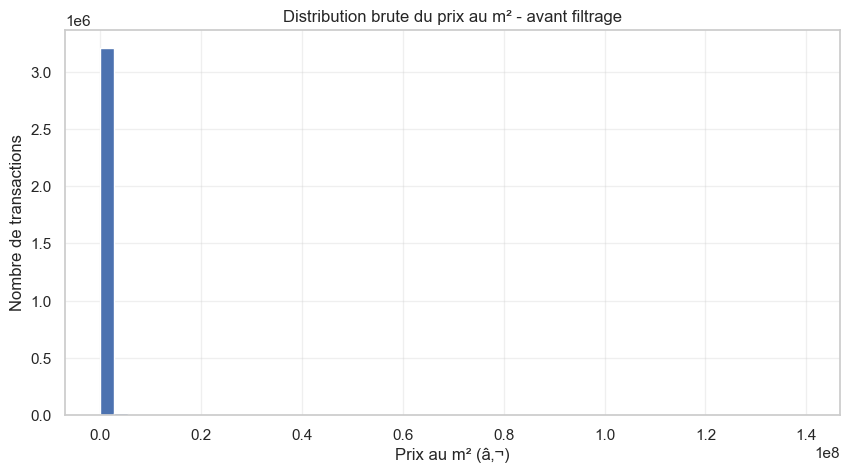

,prix_m2
count,"3,231,121.00"
mean,"60,649.37"
std,"601,287.40"
min,0.00
1%,120.00
5%,608.11
50%,"2,743.24"
95%,"34,285.71"
99%,"1,708,333.33"
max,"139,684,432.00"


In [11]:
# Visualisation brute : elle sert à démontrer l'hétérogénéité de la distribution de la variable cible
prix_brut = df_demo["prix_m2"].dropna()

plt.figure(figsize=(10, 5))
plt.hist(prix_brut, bins=50)
plt.title("Distribution brute du prix au m² - avant filtrage")
plt.xlabel("Prix au m² (â‚¬)")
plt.ylabel("Nombre de transactions")
plt.grid(alpha=0.3)
plt.show()

display(prix_brut.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame("prix_m2"))

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des résultats</h3>
  <div style="color: #4b5563; font-size: 14px;">Le prix au m² brut conserve des valeurs incompatibles avec une analyse résidentielle comparable : le 99e percentile dépasse 1,7 M€/m² et le maximum atteint un niveau aberrant. La médiane reste utile, mais les queues de distribution doivent être neutralisées.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision de filtrage</h3>
  <div style="color: #4b5563; font-size: 14px;">Le filtrage combine des bornes de surface et des quantiles de prix au m². Ce choix ne prétend pas corriger définitivement DVF ; il vise à construire une base lisible pour le cadrage, en limitant l’influence des mutations atypiques ou incomplètes.</div>
</div>

In [12]:
# Dans cette étape, on élimine statistiquement et prudemment les valeurs extrêmes pour stabiliser les analyses descriptives.
# Objectif : conserver un coeur de marché lisible sans prêtendre supprimer toute atypie réelle.

df_filtered = df_demo.copy()

# 1) On ne garde que des transactions avec un prix au m² exploitable.
# Les prix nuls/négatifs ou manquants empêchent une interprétation économique cohérente.
mask_base = (
    df_filtered["prix_m2"].notna()
    & df_filtered["prix_m2"].gt(0)
    & df_filtered["valeur_fonciere"].notna()
    & df_filtered["surface_reference"].notna()
)
df_filtered = df_filtered.loc[mask_base].copy()

# 2) Bornes métier sur la surface (m²) pour retirer erreurs de saisie évidentes.
SURFACE_MIN, SURFACE_MAX = 9, 500

# 3) Application pour l'heure de simples bornes statistiques sur le prix au m²:.
# On retire les 1% les plus bas et les 1% les plus hauts.
# Ce compromis limite l'influence des queues extrêmes sur les comparaisons.
q_bas, q_haut = df_filtered["prix_m2"].quantile([0.01, 0.99])
PRIX_M2_MIN = int(q_bas)
PRIX_M2_MAX = int(q_haut)

# 4) Combinaison des filtres pour obtenir le périmètre final de cadrage.
mask_filtrage = (
    df_filtered["surface_reference"].between(SURFACE_MIN, SURFACE_MAX)
    & df_filtered["prix_m2"].between(PRIX_M2_MIN, PRIX_M2_MAX)
)

df_filtered = df_filtered.loc[mask_filtrage].copy()

print(
    "Bornes retenues -> "
    f"surface: [{SURFACE_MIN}, {SURFACE_MAX}] m² | "
    f"prix_m2: [{PRIX_M2_MIN:,.0f}, {PRIX_M2_MAX:,.0f}]"
)

afficher_reduction(
    lignes_avant=len(df_demo),
    lignes_apres=len(df_filtered),
    explication_filtrage="Filtrage outliers (bornes surface + quantiles prix_m2)",
    justification=(
        "On se concentre sur la zone de marché la plus comparable pour éviter "
        "que des observations extrêmes dominent les analyses de cadrage."
    ),
)

display(
    df_filtered[["prix_m2", "surface_reference", "valeur_fonciere"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

# Alias conservé pour compatibilité avec les cellules aval déjà écrites.
df_lisible = df_filtered.copy()

Bornes retenues -> surface: [9, 500] m² | prix_m2: [120, 1,708,333]
Filtrage outliers (bornes surface + quantiles prix_m2)
On se concentre sur la zone de marché la plus comparable pour éviter que des observations extrêmes dominent les analyses de cadrage.
Lignes avant : 9,350,729
Lignes après : 3,127,724
Part conservée : 33.4%


,count,mean,std,min,1%,5%,50%,95%,99%,max
prix_m2,"3,127,724.00","13,910.71","82,567.86",120.00,312.50,714.29,"2,755.10","23,181.82","272,076.92","1,705,522.84"
surface_reference,"3,127,724.00",84.30,54.05,9.00,12.00,22.00,75.00,177.00,298.00,500.00
valeur_fonciere,"3,127,724.00","807,450.58","5,343,504.62","1,275.00","22,000.00","50,000.00","205,000.00","1,256,500.00","10,800,000.00","606,210,300.00"


In [13]:
# Contrôle de la base analytique après filtrage.
display(
    df_lisible[["valeur_fonciere", "surface_reference", "prix_m2"]]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

print(f"Période couverte : {df_lisible['date_mutation'].min().date()} -> {df_lisible['date_mutation'].max().date()}")
print(f"Nombre de communes : {df_lisible['code_commune'].nunique():,}")

,count,mean,std,min,1%,5%,50%,95%,99%,max
valeur_fonciere,"3,127,724.00","807,450.58","5,343,504.62","1,275.00","22,000.00","50,000.00","205,000.00","1,256,500.00","10,800,000.00","606,210,300.00"
surface_reference,"3,127,724.00",84.30,54.05,9.00,12.00,22.00,75.00,177.00,298.00,500.00
prix_m2,"3,127,724.00","13,910.71","82,567.86",120.00,312.50,714.29,"2,755.10","23,181.82","272,076.92","1,705,522.84"


Période couverte : 2021-01-01 -> 2022-12-31
Nombre de communes : 32,823


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Construction d'une base analytique lisible</h3>
  <div style="color: #4b5563; font-size: 14px;">Contrôle après filtrage La base filtrée conserve plus de 3,1 M de lignes, 32.800 communes et couvre la période du 1er janvier 2021 au 31 décembre 2022. Les ordres de grandeur deviennent plus interprétables, même si les valeurs hautes restent larges.</div>
</div>

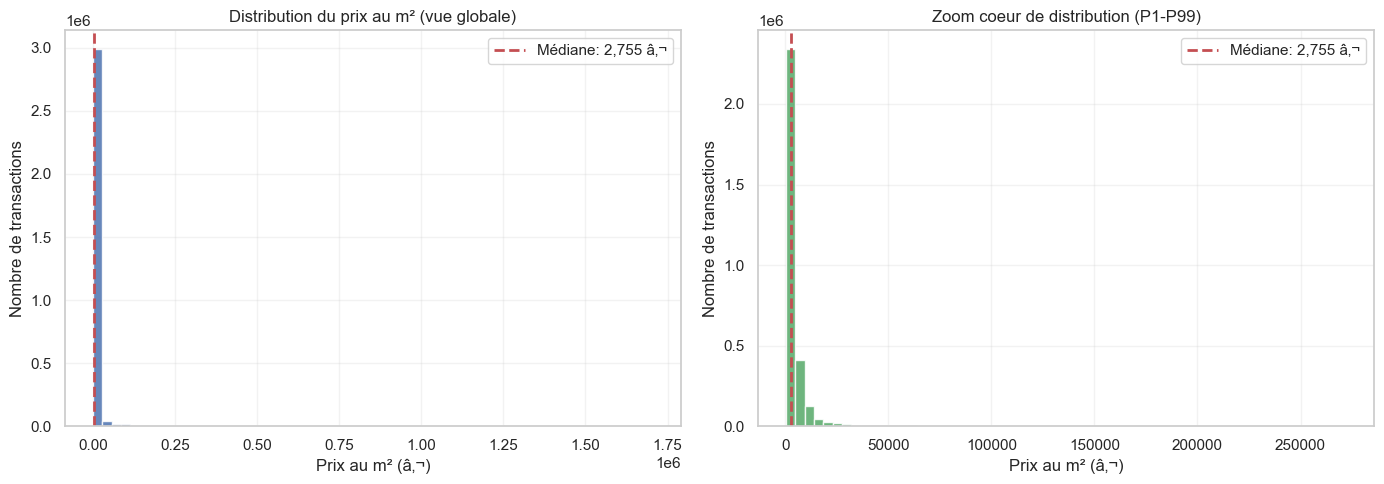

Lecture rapide : médiane = 2,755 â‚¬/m² | P1 = 312 â‚¬/m² | P99 = 272,077 â‚¬/m²


In [14]:
# Distribution du prix au m² après filtrage : vue globale + zoom central.
prix_m2 = df_lisible["prix_m2"].dropna()
q01, q99 = prix_m2.quantile([0.01, 0.99])
mediane = prix_m2.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Vue globale : montre la queue à droite.
axes[0].hist(prix_m2, bins=60, color="#4C72B0", alpha=0.85)
axes[0].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[0].set_title("Distribution du prix au m² (vue globale)")
axes[0].set_xlabel("Prix au m² (â‚¬)")
axes[0].set_ylabel("Nombre de transactions")
axes[0].grid(alpha=0.25)
axes[0].legend()

# 2) Zoom sur le coeur de distribution (1er-99e percentile) pour améliorer la lisibilité.
axes[1].hist(prix_m2, bins=60, range=(q01, q99), color="#55A868", alpha=0.85)
axes[1].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[1].set_title("Zoom coeur de distribution (P1-P99)")
axes[1].set_xlabel("Prix au m² (â‚¬)")
axes[1].set_ylabel("Nombre de transactions")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lecture rapide : médiane = {mediane:,.0f} â‚¬/m² | P1 = {q01:,.0f} â‚¬/m² | P99 = {q99:,.0f} â‚¬/m²")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Distribution du prix au m² filtré</h3>
  <div style="color: #4b5563; font-size: 14px;">La médiane ressort à 2 755 €/m². La zone centrale devient lisible, mais le P99 reste élevé à environ 272 077 €/m² : le cadrage confirme donc une amélioration, pas une normalisation complète.</div>
</div>

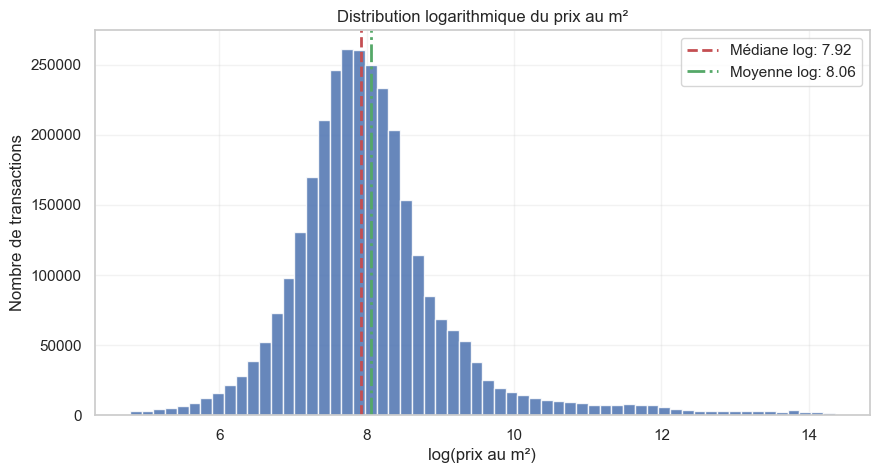

Lecture rapide : moyenne log = 8.06 | médiane log = 7.92


In [15]:
# Distribution logarithmique de la cible : lecture visuelle + repères simples.
df_lisible["log_prix_m2"] = np.log(df_lisible["prix_m2"])
log_prix = df_lisible["log_prix_m2"].dropna()
mediane_log = log_prix.median()
moyenne_log = log_prix.mean()

plt.figure(figsize=(10, 5))
plt.hist(log_prix, bins=60, color="#4C72B0", alpha=0.85)
plt.axvline(mediane_log, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane log: {mediane_log:.2f}")
plt.axvline(moyenne_log, color="#55A868", linestyle="-.", linewidth=2, label=f"Moyenne log: {moyenne_log:.2f}")
plt.title("Distribution logarithmique du prix au m²")
plt.xlabel("log(prix au m²)")
plt.ylabel("Nombre de transactions")
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Lecture rapide : moyenne log = {moyenne_log:.2f} | médiane log = {mediane_log:.2f}")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Passage en logarithme</h3>
  <div style="color: #4b5563; font-size: 14px;">La transformation logarithmique est testée pour réduire l’effet des valeurs élevées et préparer la modélisation. Elle permet de travailler sur une cible plus régulière, tout en conservant une interprétation économique du prix. La moyenne log proche de 8,06 et la médiane log proche de 7,92 indiquent une distribution plus compacte que celle du prix brut. Le log-prix devient une cible plausible pour les modèles linéaires exploratoires.</div>
</div>

In [16]:
# Sélection des appartements entre 30 et 60 m²
segment = df_lisible[
    (df_lisible["type_local"] == "Appartement") &
    (df_lisible["surface_reelle_bati"].between(30, 60))
]

# Calcul du volume et de la proportion
nb_lignes = len(segment)
part_segment = nb_lignes / len(df_lisible) * 100

print(f"{nb_lignes:,} lignes")
print(f"{part_segment:.1f} % de la base filtrée")

571,933 lignes
18.3 % de la base filtrée


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Choix du segment</h3>
  <div style="color: #4b5563; font-size: 14px;">Le segment retenu pour la première comparaison est celui des appartements de 30 à 60 m². Il représente environ 572 000 lignes, soit 18,3 % de la base filtrée, ce qui offre un compromis entre homogénéité et volume.</div>
</div>

In [17]:
# Création des variables temporelles utilisées dans les analyses suivantes.
df_lisible["annee"] = df_lisible["date_mutation"].dt.year
df_lisible["trimestre"] = df_lisible["date_mutation"].dt.to_period("Q").astype(str)
df_lisible["mois"] = df_lisible["date_mutation"].dt.to_period("M").astype(str)

display(df_lisible[["date_mutation", "annee", "trimestre", "mois"]].head())

,date_mutation,annee,trimestre,mois
1,2021-01-05,2021,2021Q1,2021-01
3,2021-01-04,2021,2021Q1,2021-01
5,2021-01-06,2021,2021Q1,2021-01
7,2021-01-04,2021,2021Q1,2021-01
14,2021-01-04,2021,2021Q1,2021-01


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Agrégation communale</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette section agrège les communes selon trois dimensions : volume, niveau médian de prix et dispersion. Elle prépare une première typologie de marchés locaux. La médiane résume le niveau de marché, l’IQR mesure la dispersion et le volume signale la robustesse statistique. Ces trois indicateurs évitent de résumer une commune à un prix moyen fragile.</div>
</div>

In [18]:
# Construction d'un segment relativement homogène pour la comparaison territoriale.
lignes_avant_segment = len(df_lisible)

base_territoire = df_lisible[
    df_lisible["type_local"].eq("Appartement")
    & df_lisible["surface_reference"].between(30, 60, inclusive="both")
].copy()

afficher_reduction(
    lignes_avant=lignes_avant_segment,
    lignes_apres=len(base_territoire),
    explication_filtrage="Restriction aux appartements de 30 à  60 m².",
    justification=(
        "Cette restriction réduit l'hétérogénéité de surface et permet une "
        "lecture plus propre des différences territoriales."
    ),
)

Restriction aux appartements de 30 à  60 m².
Cette restriction réduit l'hétérogénéité de surface et permet une lecture plus propre des différences territoriales.
Lignes avant : 3,127,724
Lignes après : 571,933
Part conservée : 18.3%


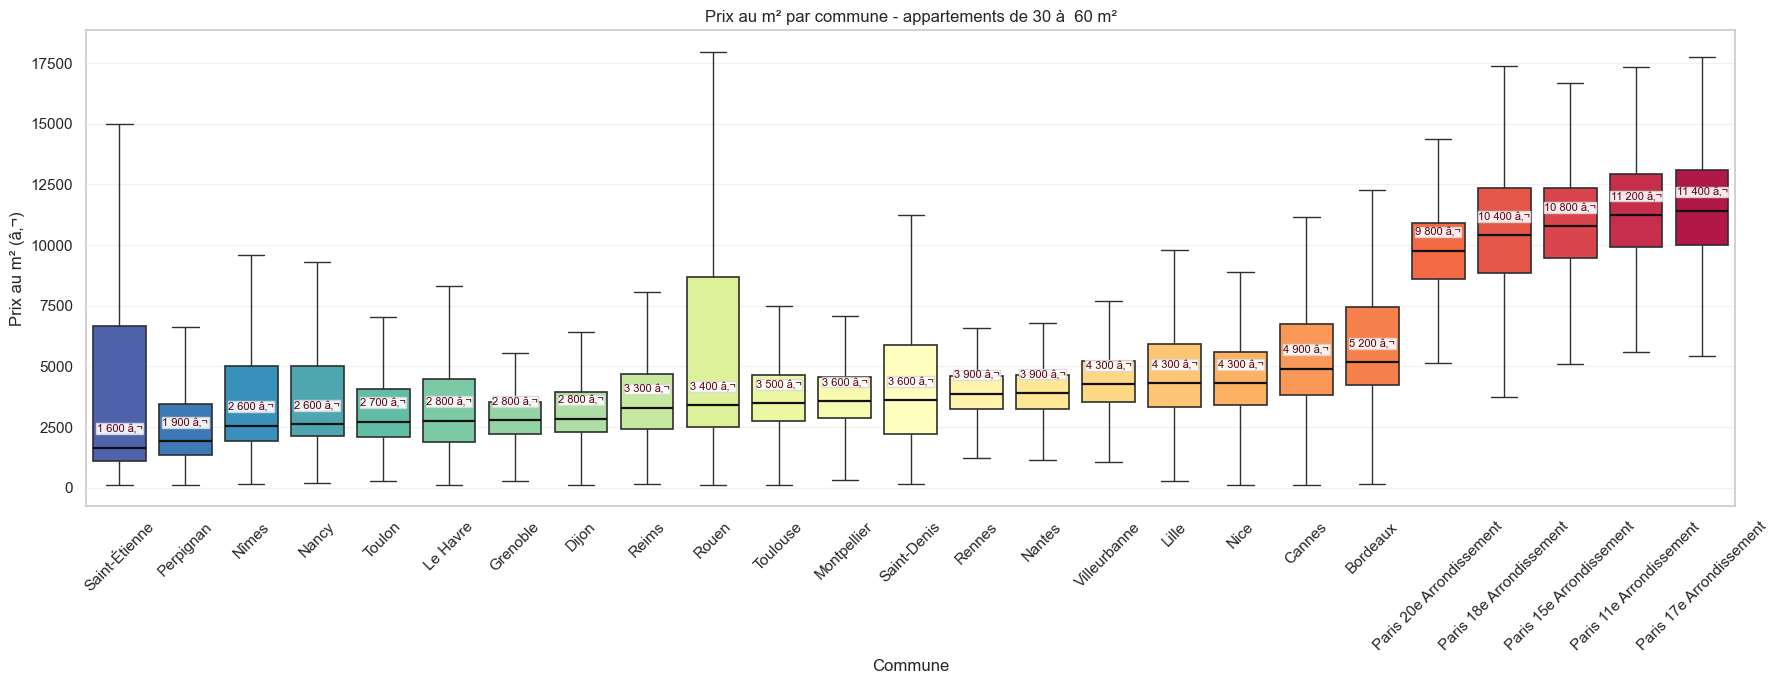

,mediane_prix_m2
nom_commune,
Paris 17e Arrondissement,11 400 â‚¬
Paris 11e Arrondissement,11 200 â‚¬
Paris 15e Arrondissement,10 800 â‚¬
Paris 18e Arrondissement,10 400 â‚¬
Paris 20e Arrondissement,9 800 â‚¬
Bordeaux,5 200 â‚¬
Cannes,4 900 â‚¬
Nice,4 300 â‚¬
Lille,4 300 â‚¬


In [19]:
# Comparaison des distributions de prix/m² pour les communes les plus représentées.
TOP_N_COMMUNES = 25

top_communes = base_territoire["nom_commune"].value_counts().head(TOP_N_COMMUNES).index
base_territoire_top = base_territoire[base_territoire["nom_commune"].isin(top_communes)].copy()

ordre_communes = (
    base_territoire_top.groupby("nom_commune")["prix_m2"]
    .median()
    .sort_values()
    .index
)

medians = (
    base_territoire_top.groupby("nom_commune")["prix_m2"]
    .median()
    .reindex(ordre_communes)
)

palette = sns.color_palette("Spectral_r", n_colors=len(ordre_communes))

fig, ax = plt.subplots(figsize=(18, 7))
sns.boxplot(
    data=base_territoire_top,
    x="nom_commune",
    y="prix_m2",
    order=ordre_communes,
    palette=palette,
    showfliers=False,
    saturation=1,
    linewidth=1.2,
    boxprops={"edgecolor": "#2F2F2F"},
    whiskerprops={"color": "#2F2F2F", "linewidth": 1},
    capprops={"color": "#2F2F2F", "linewidth": 1},
    medianprops={"color": "#111111", "linewidth": 1.6},
    ax=ax,
)

for i, mediane in enumerate(medians):
    etiquette = f"{int(round(mediane / 100) * 100):,} €".replace(",", " ")
    ax.annotate(
        etiquette,
        xy=(i, mediane),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
        color="#5C0011",
        bbox={"facecolor": "white", "edgecolor": "#D9D9D9", "alpha": 0.9, "pad": 0.25},
    )

ax.set_title("Prix au m² par commune - appartements de 30 à  60 m²")
ax.set_xlabel("Commune")
ax.set_ylabel("Prix au m² (â‚¬)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

tableau_medianes = (
    base_territoire_top.groupby("nom_commune")["prix_m2"]
    .median()
    .sort_values(ascending=False)
    .rename("mediane_prix_m2")
    .to_frame()
)
tableau_medianes["mediane_prix_m2"] = (
    tableau_medianes["mediane_prix_m2"]
    .map(lambda x: f"{int(round(x / 100) * 100):,} €".replace(",", " "))
)

display(tableau_medianes)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Comparaison des communes</h3>
  <div style="color: #4b5563; font-size: 14px;">Les communes les plus représentées sont comparées par distribution de prix au m². L’objectif n’est pas de classer définitivement les villes, mais d’observer si la localisation porte un signal de prix robuste. Les communes à prix médian élevé ne sont pas nécessairement les plus homogènes. Paris concentre des niveaux élevés avec une dispersion significative, tandis que certaines villes régionales présentent des marchés plus resserrés.</div>
</div>

In [20]:
# Test non paramétrique des différences de distributions entre communes.
# Le test de Kruskal-Wallis ne prouve pas une causalité territoriale.
# Il vérifie simplement si les distributions observées diffèrent fortement.
groupes_communes = [
    groupe["prix_m2"].values
    for _, groupe in base_territoire_top.groupby("nom_commune")
    if len(groupe) >= 30
]

stat_kruskal, p_value_kruskal = kruskal(*groupes_communes)

print(f"Statistique de Kruskal-Wallis : {stat_kruskal:,.2f}")
print(f"p-value : {p_value_kruskal:.3e}")

Statistique de Kruskal-Wallis : 31,600.39
p-value : 0.000e+00


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Test statistique</h3>
  <div style="color: #4b5563; font-size: 14px;">Le test de Kruskal-Wallis est utilisé car les distributions de prix ne sont pas supposées normales. Une p-value quasi nulle indique que les distributions communales ne peuvent pas être considérées comme identiques. La commune devra être conservée comme variable explicative ou comme niveau d’agrégation. Le résultat statistique ne suffit pas à expliquer les causes, mais il valide l’intérêt d’un enrichissement territorial plus fin dans la suite du projet.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Premières approche d'une typologie exploratoire des communes</h3>
  <div style="color: #4b5563; font-size: 14px;">Un clustering exploratoire est appliqué pour repérer des familles de communes. Cette typologie reste descriptive : elle sert à formuler des hypothèses de marché, pas à produire une segmentation définitive. Comme déjà évoqué, le clustering mobilise le volume, la médiane de prix au m² et la dispersion interquartile. Ces variables combinent taille de marché, niveau de valorisation et hétérogénéité locale.</div>
</div>

In [21]:
 #importation de la fonction iqr
from scipy.stats import iqr

# Construction d'une synthèse statistique par commune.
# Pour chaque commune, on calcule :
# - le nombre de transactions observées,
# - le prix médian au m²,
# - la dispersion des prix via l'écart interquartile (IQR).
synthese_communes = (
    base_territoire_top.groupby("nom_commune", dropna=False)
    .agg(
        # Nombre total de transactions par commune
        volume=("prix_m2", "size"),

        # Prix médian au m² : mesure centrale robuste aux valeurs extrêmes
        prix_m2_med=("prix_m2", "median"),

        # Écart interquartile : mesure la dispersion des prix
        # entre le 1er et le 3e quartile
        prix_m2_iqr=("prix_m2", iqr),
    )
    .reset_index()
)

# Affiche les 15 communes ayant les prix médians au m² les plus élevés
display(
    synthese_communes
    .sort_values("prix_m2_med", ascending=False)
    .head(15)
)

,nom_commune,volume,prix_m2_med,prix_m2_iqr
13,Paris 17e Arrondissement,2924,"11,411.65","3,108.86"
11,Paris 11e Arrondissement,3043,"11,240.00","3,002.75"
12,Paris 15e Arrondissement,3954,"10,776.82","2,891.11"
14,Paris 18e Arrondissement,4345,"10,409.09","3,476.19"
15,Paris 20e Arrondissement,2507,"9,760.00","2,319.61"
0,Bordeaux,4637,"5,175.00","3,208.33"
1,Cannes,3221,"4,905.66","2,929.47"
9,Nice,8979,"4,307.69","2,202.02"
5,Lille,4170,"4,302.17","2,602.19"
24,Villeurbanne,2535,"4,255.14","1,691.15"


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des distributions communales</h3>
  <div style="color: #4b5563; font-size: 14px;">Les arrondissements parisiens dominent nettement les médianes observées, autour de 9 800 à 11 400 €/m², tandis que des grandes villes régionales se situent sur des niveaux plus bas. Le signal territorial est donc très marqué.</div>
</div>

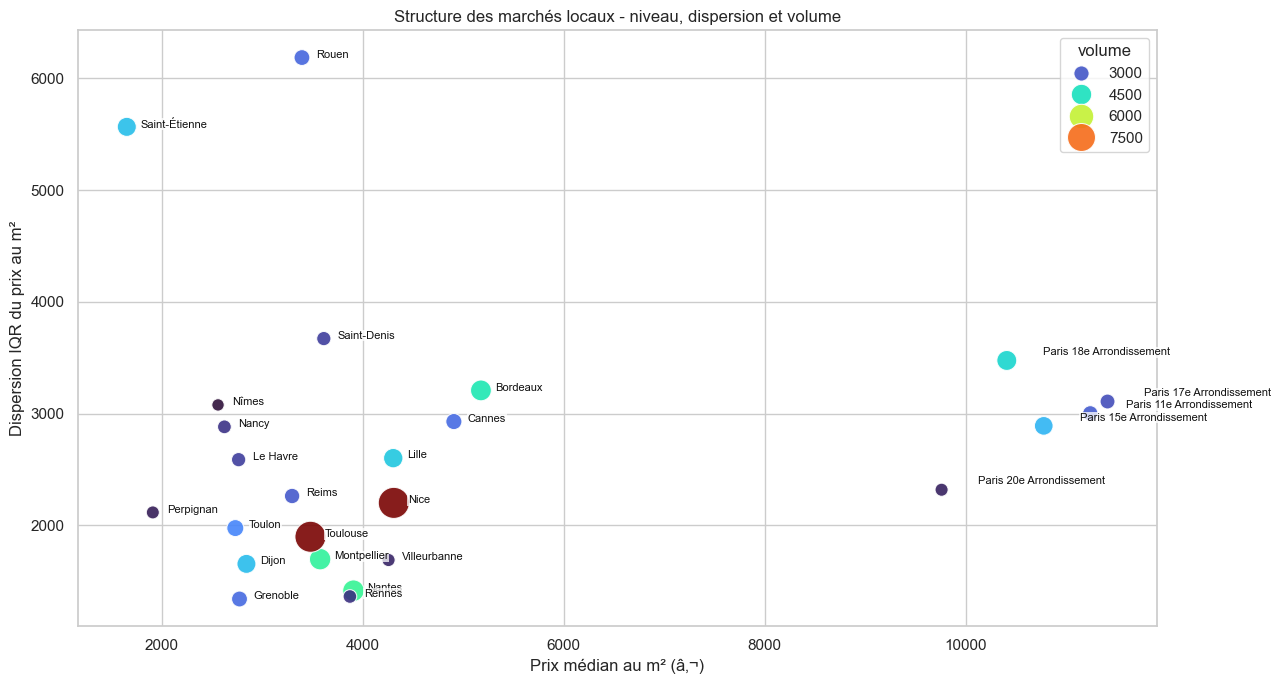

In [22]:
# Sécurisation des types pour seaborn.
synthese_communes = synthese_communes.copy()
synthese_communes["volume"] = synthese_communes["volume"].astype(float)
synthese_communes["prix_m2_med"] = synthese_communes["prix_m2_med"].astype(float)
synthese_communes["prix_m2_iqr"] = synthese_communes["prix_m2_iqr"].astype(float)

plt.figure(figsize=(13, 7))

sns.scatterplot(
    data=synthese_communes,
    x="prix_m2_med",
    y="prix_m2_iqr",
    size="volume",
    hue="volume",
    palette="turbo",  # palette vive et lisible
    sizes=(80, 500),
    alpha=0.9,
    legend="brief",
)

for _, row in synthese_communes.iterrows():
    label = row["nom_commune"]
    offset_x = 26 if "Paris" in label else 10
    offset_y = 6 if "Paris" in label else 2

    plt.annotate(
        label,
        (row["prix_m2_med"], row["prix_m2_iqr"]),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=8,
        color="#111111",
        ha="left",
        va="center",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.4},
    )

plt.title("Structure des marchés locaux - niveau, dispersion et volume")
plt.xlabel("Prix médian au m² (â‚¬)")
plt.ylabel("Dispersion IQR du prix au m²")
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Structure des marchés immobiliers locaux</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce graphique croise trois dimensions : prix médian au m², dispersion des prix (IQR), volume de transactions. L’objectif est de comparer : niveau de prix, homogénéité des marchés, intensité de l’activité. Un marché parisien à part Les arrondissements parisiens se détachent nettement du reste du panel. Les 15e, 17e et 18e affichent les niveaux de prix les plus élevés, avec des profils différents : le 18e combine prix élevés et forte dispersion, le 20e reste plus homogène malgré des prix comparables. Cette opposition reflète des structures de marché différentes selon les quartiers. Des métropoles régionales aux profils contrastés Bordeaux, Nice, Lille ou Toulouse occupent une position intermédiaire : prix élevés, volumes importants, mais niveaux de dispersion variables. Bordeaux et Nice apparaissent plus fragmentées, avec des écarts de prix importants selon les secteurs. Toulouse se distingue par : un volume très élevé, des prix encore plus accessibles, une dispersion plus contenue. Le profil est plus proche d’un marché dynamique et liquide. Des marchés plus hétérogènes malgré des prix modérés Rouen, Saint-Étienne ou Saint-Denis présentent une forte dispersion des prix malgré des niveaux médians plus faibles. Cela traduit souvent : des écarts importants entre quartiers, un parc immobilier hétérogène, ou des dynamiques locales très contrastées. Rouen ressort particulièrement avec une dispersion très élevée au regard de son niveau de prix. Des marchés plus homogènes Rennes, Nantes, Grenoble ou Dijon présentent des profils plus resserrés : dispersion limitée, structure de prix plus stable, segmentation moins marquée. Ces marchés apparaissent généralement plus lisibles et plus faciles à modéliser. Une relation prix / dispersion non linéaire Les marchés les plus chers sont souvent plus dispersés, mais la relation reste imparfaite. Deux villes peuvent afficher des prix proches avec des structures très différentes : Paris 20e reste relativement homogène, Rouen présente une dispersion extrême malgré des prix plus modérés. Le niveau de prix seul ne suffit donc pas à caractériser un marché local. Intérêt analytique Cette représentation permet : d’identifier des groupes de marchés similaires, de repérer des territoires atypiques, de mesurer l’hétérogénéité locale, et de préparer des approches de clustering ou de scoring territorial. L’IQR peut notamment devenir une variable utile pour : la segmentation, la détection d’anomalies, ou l’évaluation du risque local. Conclusion Le graphique montre que les marchés immobiliers locaux se différencient autant par leur niveau de prix que par leur structure interne. À prix équivalent, certaines villes restent homogènes alors que d’autres présentent des écarts très importants selon les quartiers ou les types de biens. Cette lecture apporte une vision plus fine du territoire qu’une simple comparaison des prix médians.</div>
</div>

c:\Users\club_\anaconda_1124\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


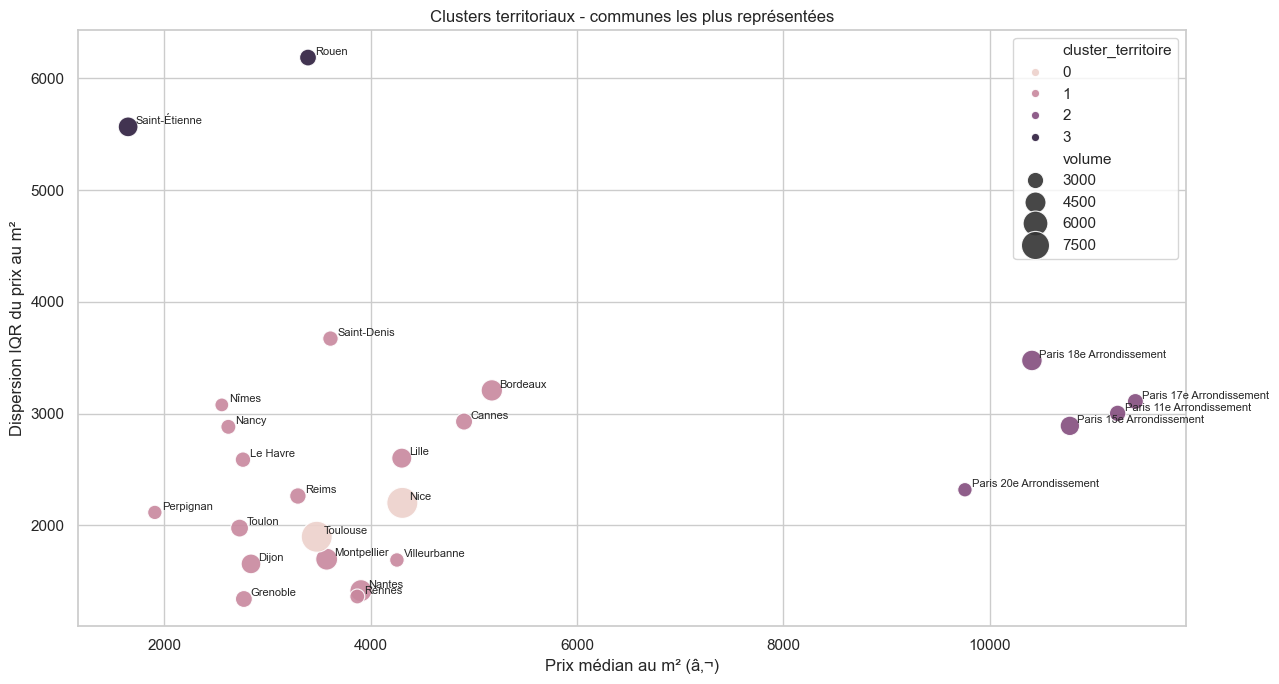

In [23]:
# Clustering exploratoire des communes à partir de trois dimensions de marché.
N_CLUSTERS_COMMUNES = 4

features_cluster = synthese_communes[["volume", "prix_m2_med", "prix_m2_iqr"]].copy()

scaler_communes = StandardScaler()
features_cluster_scaled = scaler_communes.fit_transform(features_cluster)

kmeans_communes = KMeans(
    n_clusters=N_CLUSTERS_COMMUNES,
    random_state=RANDOM_STATE,
    n_init=10,
)

synthese_communes["cluster_territoire"] = kmeans_communes.fit_predict(features_cluster_scaled)

plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=synthese_communes,
    x="prix_m2_med",
    y="prix_m2_iqr",
    hue="cluster_territoire",
    size="volume",
    sizes=(100, 500),
    alpha=0.9,
)

for _, row in synthese_communes.iterrows():
    plt.annotate(
        row["nom_commune"],
        (row["prix_m2_med"], row["prix_m2_iqr"]),
        xytext=(5, 2),
        textcoords="offset points",
        fontsize=8,
    )

plt.title("Clusters territoriaux - communes les plus représentées")
plt.xlabel("Prix médian au m² (â‚¬)")
plt.ylabel("Dispersion IQR du prix au m²")
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Segmentation des marchés immobiliers</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce graphique reprend les variables précédentes : prix médian au m², dispersion des prix, volume de transactions, mais ajoute une segmentation automatique des communes selon leur profil de marché. Chaque couleur correspond à un groupe de territoires aux caractéristiques proches. Un cluster parisien distinct Les arrondissements parisiens forment un groupe clairement séparé : niveaux de prix très élevés, volumes importants, dispersion marquée. Le 18e ressort par une forte hétérogénéité, alors que le 20e apparaît plus homogène malgré des prix comparables. Paris fonctionne ici comme un marché à part entière. Des marchés atypiques et très dispersés Rouen et Saint-Étienne se distinguent par : des prix relativement modérés, mais une dispersion très forte. Ce profil traduit généralement : des écarts importants entre quartiers, un parc immobilier hétérogène, ou des dynamiques locales très contrastées. Ces marchés apparaissent aussi plus difficiles à modéliser. Le cœur du marché intermédiaire La majorité des villes se regroupent dans une zone plus compacte : Rennes, Nantes, Dijon, Grenoble, Reims, Toulon, Le Havre. Ces marchés partagent : des prix plus contenus, une dispersion modérée, des volumes relativement stables. Ils représentent un profil plus homogène et plus lisible. Toulouse et Nice : des marchés plus dynamiques Toulouse se distingue par : un volume très élevé, des prix encore accessibles, une dispersion contenue. Le profil est celui d’un marché particulièrement liquide. Nice présente au contraire : des prix plus élevés, une dispersion plus marquée, une structure probablement influencée par le marché secondaire et touristique. Ce que montre le clustering Les groupes ne sont pas construits uniquement à partir du niveau de prix. Le clustering intègre aussi : l’hétérogénéité des marchés, leur structure, et leur intensité transactionnelle. Deux villes proches en prix peuvent donc appartenir à des groupes très différents. Intérêt analytique Cette approche permet : de segmenter automatiquement les territoires, d’identifier des marchés atypiques, d’améliorer les modèles prédictifs, ou de construire des scores territoriaux. Elle constitue également une bonne base pour : un dashboard interactif, une cartographie dynamique, ou un moteur de recommandation immobilière. Limites Le résultat dépend fortement : des variables retenues, de leur normalisation, et du nombre de clusters choisi. Ces groupes doivent donc être interprétés comme des profils de marché, et non comme des catégories fixes. Conclusion Le graphique met en évidence plusieurs logiques territoriales : marchés premium, marchés homogènes, marchés dynamiques, marchés fortement fragmentés. Cette lecture apporte une vision plus structurelle du marché immobilier qu’une simple comparaison des prix au m².</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision pour la suite</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette première typologie justifie la création de notebooks dédiés aux typologies de marché et aux enrichissements territoriaux. Elle fournit une preuve empirique de l’intérêt d’aller au-delà des seules caractéristiques du bien.</div>
</div>

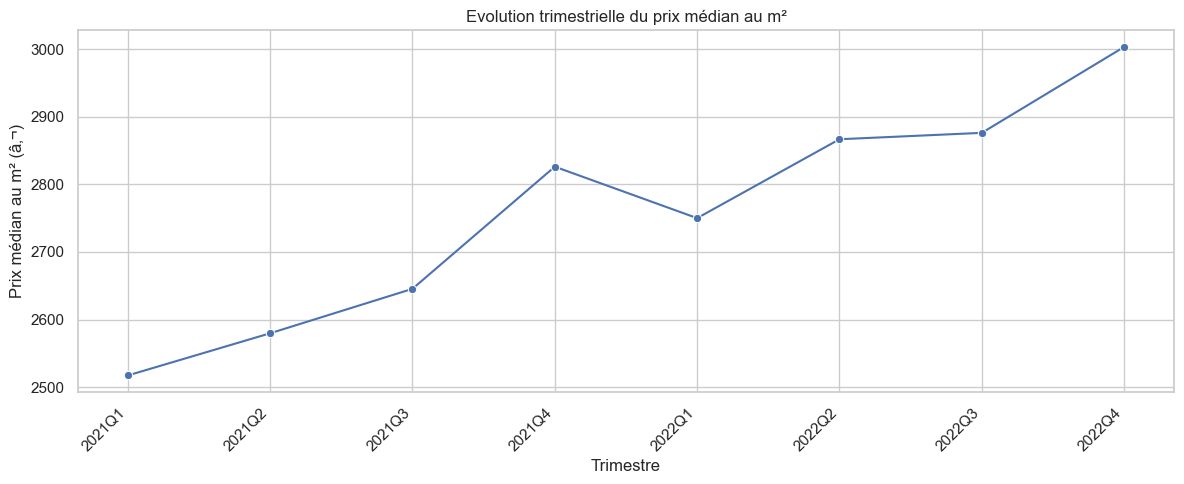

,trimestre,volume,prix_m2_med
0,2021Q1,334352,"2,517.36"
1,2021Q2,409798,"2,579.73"
2,2021Q3,442907,"2,645.45"
3,2021Q4,415527,"2,826.09"
4,2022Q1,348426,"2,750.00"
5,2022Q2,397600,"2,866.67"
6,2022Q3,406646,"2,876.11"
7,2022Q4,372468,"3,003.18"


In [24]:
# Evolution globale du prix médian au m² par trimestre.
trend_global = (
    df_lisible.groupby("trimestre", dropna=False)
    .agg(
        volume=("prix_m2", "size"),
        prix_m2_med=("prix_m2", "median"),
    )
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.lineplot(data=trend_global, x="trimestre", y="prix_m2_med", marker="o")
plt.title("Evolution trimestrielle du prix médian au m²")
plt.xlabel("Trimestre")
plt.ylabel("Prix médian au m² (â‚¬)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(trend_global)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Evolution trimestrielle du prix médian au m²</h3>
  <div style="color: #4b5563; font-size: 14px;">Le prix médian au m² progresse nettement entre début 2021 et fin 2022 : 517 €/m² au T1 2021, 003 €/m² au T4 2022. La hausse approche 20 % sur la période. Une dynamique globalement haussière La progression reste relativement continue sur l’ensemble des trimestres, avec plusieurs accélérations : fin 2021, mi-2022, puis au T4 2022. Malgré le changement de contexte économique en 2022, les prix continuent donc de progresser. Un ralentissement temporaire début 2022 Le T1 2022 marque une phase de respiration : recul du prix médian, baisse des volumes de transactions. Ce ralentissement reste toutefois temporaire, la dynamique repartant rapidement dès le trimestre suivant. Des volumes encore élevés Les volumes restent soutenus sur toute la période, entre environ 330 000 et 440 000 transactions par trimestre. Le pic d’activité apparaît au T3 2021 avec plus de 442 000 ventes, avant un ralentissement progressif en 2022. La hausse des prix ne provoque donc pas immédiatement de décrochage du marché. Fin 2022 : volumes en baisse, prix toujours élevés Le T4 2022 montre une configuration intéressante : les volumes reculent, mais les prix continuent de progresser. Ce décalage correspond souvent aux phases de transition du marché immobilier : l’activité ralentit avant les prix. Conclusion Entre 2021 et 2022, le marché reste globalement haussier malgré un ralentissement progressif de l’activité. Les premiers signes de changement apparaissent surtout du côté des volumes, alors que les prix résistent encore en fin de période.</div>
</div>

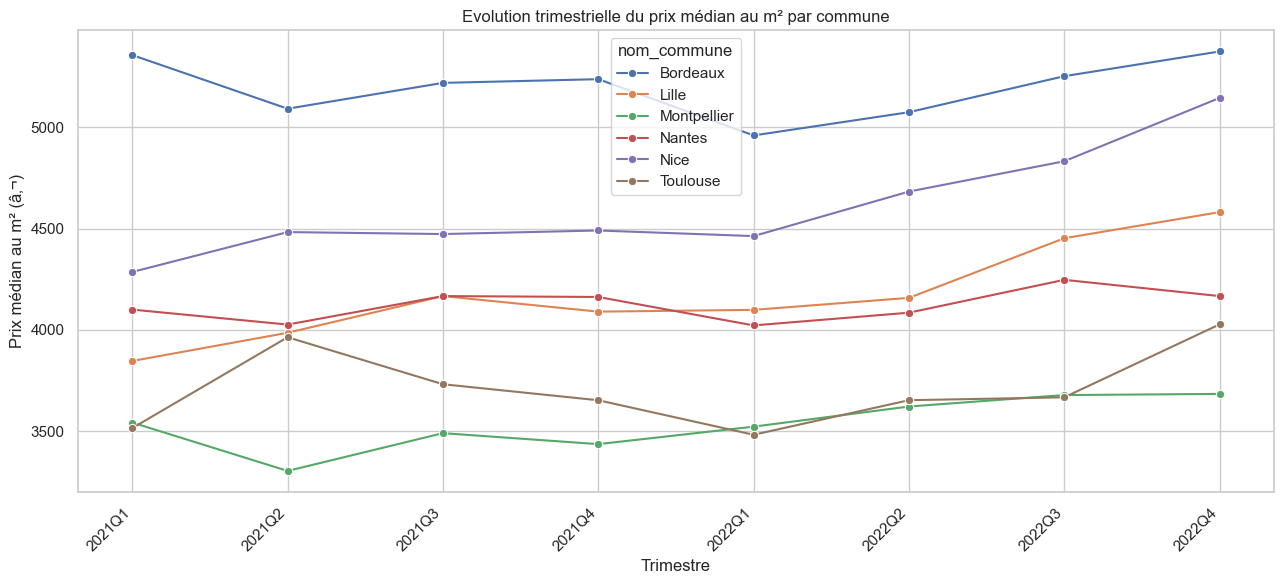

In [25]:
# Comparaison de trajectoires locales sur quelques communes fréquentes.
N_COMMUNES_DYN = 6

communes_dyn = df_lisible["nom_commune"].value_counts().head(N_COMMUNES_DYN).index

trend_communes = (
    df_lisible[df_lisible["nom_commune"].isin(communes_dyn)]
    .groupby(["trimestre", "nom_commune"], dropna=False)
    .agg(prix_m2_med=("prix_m2", "median"))
    .reset_index()
)

plt.figure(figsize=(13, 6))
sns.lineplot(
    data=trend_communes,
    x="trimestre",
    y="prix_m2_med",
    hue="nom_commune",
    marker="o",
)
plt.title("Evolution trimestrielle du prix médian au m² par commune")
plt.xlabel("Trimestre")
plt.ylabel("Prix médian au m² (â‚¬)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Evolution trimestrielle du prix médian au m² par commune</h3>
  <div style="color: #4b5563; font-size: 14px;">Les trajectoires restent globalement haussières entre 2021 et 2022, mais les dynamiques diffèrent nettement selon les villes. Bordeaux reste au-dessus du groupe Bordeaux conserve les niveaux de prix les plus élevés sur l’ensemble de la période. Après quelques phases de stabilisation en 2021 et début 2022, la hausse reprend progressivement en fin de période. Le marché reste structurellement tendu. Nice accélère fortement en 2022 Nice présente l’une des dynamiques les plus marquées du panel. La hausse s’accélère nettement à partir de mi-2022 jusqu’à dépasser 5 100 €/m². Le marché semble porté à la fois par l’attractivité résidentielle et la pression sur l’offre. Lille progresse de manière régulière Lille suit une trajectoire plus stable et progressive. Après une année 2021 relativement calme, les prix accélèrent en 2022, notamment sur les derniers trimestres. La volatilité reste plus limitée que dans d’autres métropoles. Nantes marque davantage le pas Nantes évolue dans une fourchette plus resserrée autour de 4 000–4 250 €/m². La progression reste visible mais moins marquée que dans les autres grandes villes du panel. Le marché semble entrer plus tôt dans une phase de stabilisation. Montpellier reste plus stable Montpellier présente des variations relativement limitées sur l’ensemble de la période. Après un léger recul en 2021, les prix repartent progressivement sans forte accélération. Le marché apparaît plus équilibré et moins tendu. Toulouse : une trajectoire plus irrégulière Toulouse montre une évolution moins linéaire : hausse marquée début 2021, repli progressif jusqu’au T1 2022, rebond net en fin de période. Cette volatilité peut refléter une sensibilité plus forte aux cycles de marché ou à la composition des ventes. Des dynamiques locales très différentes Certaines métropoles conservent une forte accélération en 2022 : Nice, Bordeaux, Lille. D’autres montrent davantage de stabilisation : Nantes, Montpellier. Le ralentissement du marché apparaît donc très hétérogène selon les territoires. Conclusion Derrière la tendance nationale haussière, les trajectoires locales restent très contrastées. Certaines villes continuent d’accélérer alors que d’autres semblent déjà entrer dans une phase de ralentissement. Cette hétérogénéité confirme l’importance d’une lecture territoriale fine du marché immobilier.</div>
</div>

c:\Users\club_\anaconda_1124\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


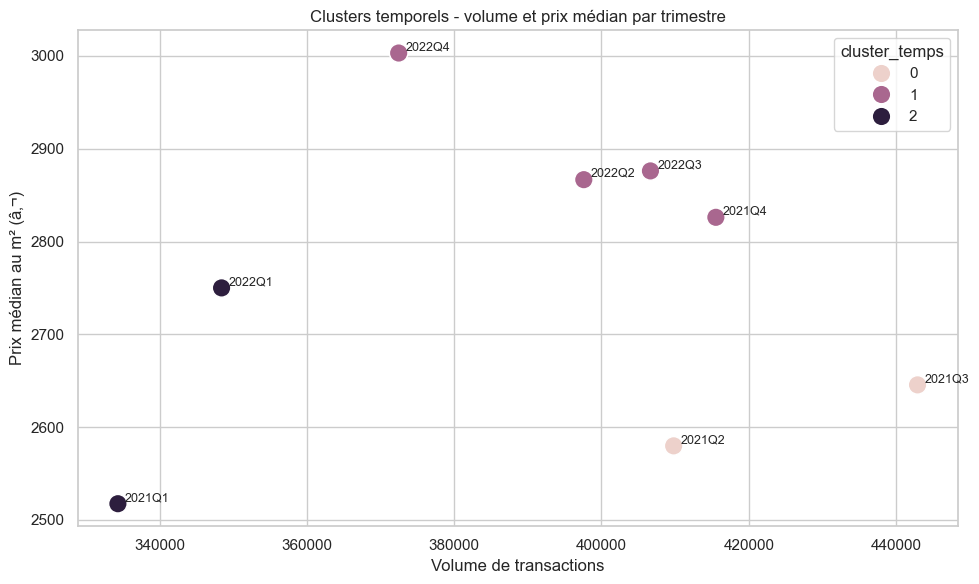

In [26]:
# Clustering exploratoire des trimestres.
N_CLUSTERS_TEMPS = 3

features_temps = trend_global[["volume", "prix_m2_med"]].copy()

scaler_temps = StandardScaler()
features_temps_scaled = scaler_temps.fit_transform(features_temps)

kmeans_temps = KMeans(
    n_clusters=N_CLUSTERS_TEMPS,
    random_state=RANDOM_STATE,
    n_init=10,
)

trend_global["cluster_temps"] = kmeans_temps.fit_predict(features_temps_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=trend_global,
    x="volume",
    y="prix_m2_med",
    hue="cluster_temps",
    s=180,
)

for _, row in trend_global.iterrows():
    plt.annotate(
        row["trimestre"],
        (row["volume"], row["prix_m2_med"]),
        xytext=(5, 2),
        textcoords="offset points",
        fontsize=9,
    )

plt.title("Clusters temporels - volume et prix médian par trimestre")
plt.xlabel("Volume de transactions")
plt.ylabel("Prix médian au m² (â‚¬)")
plt.tight_layout()
plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Clusters temporels : volume et prix médian par trimestre</h3>
  <div style="color: #4b5563; font-size: 14px;">Ce graphique regroupe les trimestres selon leur profil de marché : niveau de prix, volume de transactions. Le clustering fait apparaître plusieurs phases distinctes entre 2021 et 2022. Début 2021 : phase de reprise 2021Q1 apparaît isolé avec : des volumes plus faibles, des prix encore relativement bas. Le marché semble alors en phase de reprise avant l’accélération observée sur les trimestres suivants. : forte dynamique transactionnelle 2021Q2 et surtout 2021Q3 correspondent au pic d’activité : volumes très élevés, prix encore contenus. Le T3 2021 dépasse 440 000 transactions et marque le point haut du cycle en volume. Cette phase reflète un marché particulièrement fluide, soutenu par des conditions de financement encore favorables. Fin 2021 et année 2022 : changement de régime À partir de 2021Q4, le profil du marché évolue : les prix continuent de progresser, mais les volumes commencent à ralentir. Cette dynamique devient particulièrement visible en 2022. Le marché reste tendu, mais l’activité perd progressivement en intensité. 2022Q1 : un trimestre de transition 2022Q1 se distingue par : un recul temporaire des prix, une baisse plus marquée des volumes. Le ralentissement reste toutefois limité et les prix repartent rapidement à la hausse dès les trimestres suivants. 2022Q4 : des prix élevés malgré le recul de l’activité Le T4 2022 combine : les prix médians les plus élevés, des volumes inférieurs à ceux de 2021. Cette configuration correspond souvent à une phase de ralentissement où l’activité se contracte avant les prix. Le marché devient moins fluide, mais les niveaux de prix résistent encore. Trois grandes phases ressortent Phase 1 — Reprise 2021Q1 Prix et volumes encore relativement bas. Phase 2 — Expansion 2021Q2 à 2021Q3 Forte hausse des transactions avec progression progressive des prix. Phase 3 — Ralentissement Fin 2021 et année 2022 Prix toujours élevés mais ralentissement progressif de l’activité. Conclusion Le graphique met en évidence la transition : d’un marché très actif en 2021, vers un marché plus tendu et moins fluide en 2022. Les volumes semblent ralentir avant les prix, un comportement classique dans les cycles immobiliers.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Décision analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">Cette segmentation temporelle confirme l’intérêt d’intégrer des variables de période dans les futurs modèles. Les effets calendaires et les changements de régime de marché pourront être étudiés plus finement dans des notebooks dédiés à l’évolution temporelle des transactions.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Modélisation exploratoire</h3>
  <div style="color: #4b5563; font-size: 14px;">La modélisation sert ici de test de valeur ajoutée. L’objectif est de comparer une baseline centrée sur le bien à un modèle enrichi par des variables territoriales et temporelles.</div>
</div>

In [27]:
# Préparation d'une base unique pour comparer les deux modèles.
# Les deux modèles doivent utiliser exactement les mémes lignes.
MAX_COMMUNES_MODEL = 200

colonnes_model = [
    "prix_m2",
    "log_prix_m2",
    "surface_reference",
    "nombre_pieces_principales",
    "type_local",
    "code_commune",
    "annee",
    "trimestre",
]





In [28]:
# Construction de la base de modélisation
df_model = df_lisible[colonnes_model].copy()

# Suppression des observations incomplètes
df_model = df_model.dropna(
    subset=[
        "prix_m2",
        "log_prix_m2",
        "surface_reference",
        "type_local",
        "code_commune",
        "annee",
        "trimestre",
    ]
)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Contrôle avant resserrement métier</h3>
  <div style="color: #4b5563; font-size: 14px;">La distribution pré-filtrage modèle rappelle que le cadrage général ne suffit pas pour l’apprentissage. Les valeurs hautes restent trop influentes pour une baseline interprétable.</div>
</div>

In [29]:
df_model["prix_m2"].describe(
    percentiles=[0.95, 0.99, 0.995, 0.999]
)

count   3,127,724.00
mean       13,910.71
std        82,567.86
min           120.00
50%         2,755.10
95%        23,181.82
99%       272,076.92
99.5%     642,482.80
99.9%   1,284,965.60
max     1,705,522.84
Name: prix_m2, dtype: Float64

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Avant filtrage modèle</h3>
  <div style="color: #4b5563; font-size: 14px;">La distribution issue de la base filtrée reste encore large, avec un 99e percentile proche de 272 077 €/m². Cela confirme la nécessité d’un filtrage métier supplémentaire avant l’entraînement.</div>
</div>

In [30]:
# Filtrage métier
df_model = df_model.query(
    "surface_reference >= 15 and 500 <= prix_m2 <= 20000",
    engine="python"
).copy()

In [31]:
df_model["prix_m2"].describe(
    percentiles=[0.95, 0.99, 0.995, 0.999]
)

count   2,859,253.00
mean        3,567.59
std         2,980.90
min           500.00
50%         2,666.67
95%        10,000.00
99%        15,714.29
99.5%      17,589.85
99.9%      19,545.45
max        20,000.00
Name: prix_m2, dtype: Float64

In [ ]:
# Les pièces manquantes sont imputées simplement par la médiane.
# Ce choix est acceptable pour une baseline, mais devra être discuté dans les notebooks suivants.
df_model["nombre_pieces_principales"] = df_model["nombre_pieces_principales"].fillna(
    df_model["nombre_pieces_principales"].median()
)

# Réduction de la cardinalité des communes 
top_communes_model = (
    df_model["code_commune"]
    .value_counts()
    .head(MAX_COMMUNES_MODEL)
    .index
)

df_model["code_commune_red"] = df_model["code_commune"].where(
    df_model["code_commune"].isin(top_communes_model),
    other="autre",
)

print(f"Base modèle : {len(df_model):,} lignes")
print(f"Communes distinctes initiales : {df_model['code_commune'].nunique():,}")
print(f"Communes conservées dans l'encodage : {MAX_COMMUNES_MODEL} + modalité 'autre'")

Base modèle : 2,859,253 lignes
Communes distinctes initiales : 32,649
Communes conservées dans l'encodage : 200 + modalité 'autre'


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Après filtrage modèle</h3>
  <div style="color: #4b5563; font-size: 14px;">La base modèle compte environ 2,86 millions de lignes. Le prix médian est proche de 2 667 €/m² et le 99e percentile descend à environ 15 714 €/m², ce qui rend l’apprentissage plus stable . Les communes sont limitées aux 200 modalités les plus fréquentes, avec une modalité “autre”. Ce compromis limite la dimension du modèle tout en conservant une part importante du signal territorial.</div>
</div>

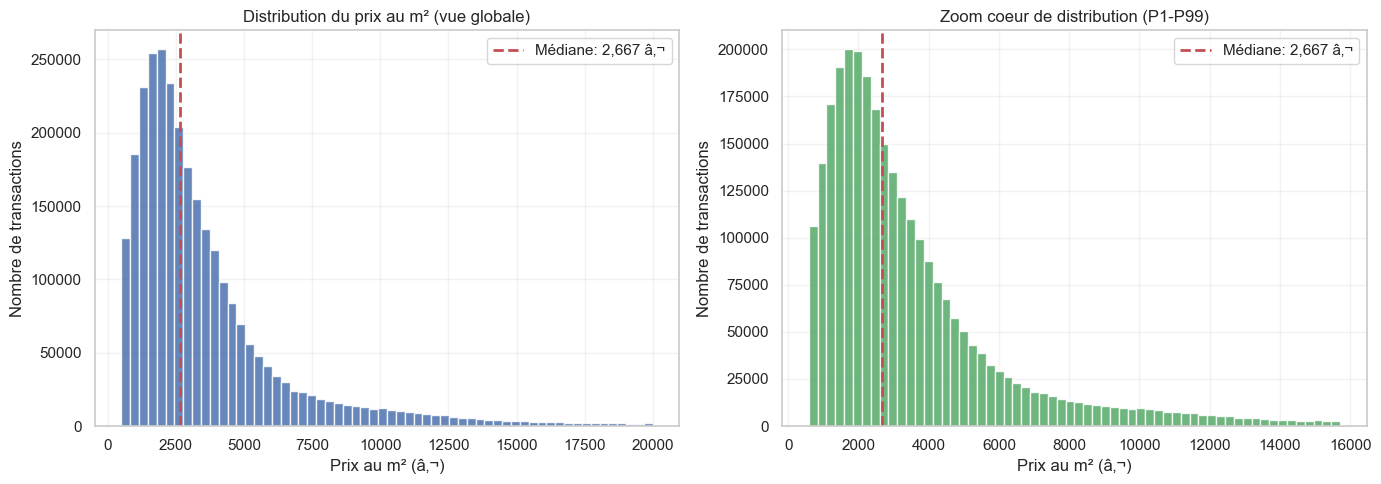

Lecture rapide : médiane = 2,667 â‚¬/m² | P1 = 583 â‚¬/m² | P99 = 15,714 â‚¬/m²


In [33]:
# Distribution du prix au m² après filtrage : vue globale + zoom central.
prix_m2 = df_model["prix_m2"].dropna()
q01, q99 = prix_m2.quantile([0.01, 0.99])
mediane = prix_m2.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Vue globale : montre la queue à droite.
axes[0].hist(prix_m2, bins=60, color="#4C72B0", alpha=0.85)
axes[0].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[0].set_title("Distribution du prix au m² (vue globale)")
axes[0].set_xlabel("Prix au m² (â‚¬)")
axes[0].set_ylabel("Nombre de transactions")
axes[0].grid(alpha=0.25)
axes[0].legend()

# 2) Zoom sur le coeur de distribution (1er-99e percentile) pour améliorer la lisibilité.
axes[1].hist(prix_m2, bins=60, range=(q01, q99), color="#55A868", alpha=0.85)
axes[1].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[1].set_title("Zoom coeur de distribution (P1-P99)")
axes[1].set_xlabel("Prix au m² (â‚¬)")
axes[1].set_ylabel("Nombre de transactions")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lecture rapide : médiane = {mediane:,.0f} â‚¬/m² | P1 = {q01:,.0f} â‚¬/m² | P99 = {q99:,.0f} â‚¬/m²")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de la distribution après filtrage</h3>
  <div style="color: #4b5563; font-size: 14px;">Malgré le filtrage métier appliqué, la distribution du prix au m² reste asymétrique avec une longue queue vers les valeurs élevées. La médiane se situe autour de 2 667 €/m², tandis que quelques marchés conservent des niveaux beaucoup plus élevés. Le zoom sur le cœur de distribution (P1-P99) montre néanmoins une concentration plus nette des observations, ce qui rend la base plus adaptée à une modélisation statistique.</div>
</div>

In [34]:
# Construction des matrices explicatives.
y = df_model["log_prix_m2"]

X_bien = df_model[
    [
        "surface_reference",
        "nombre_pieces_principales",
        "type_local",
    ]
].copy()

X_contexte = df_model[
    [
        "surface_reference",
        "nombre_pieces_principales",
        "type_local",
        "code_commune_red",
        "annee",
        "trimestre",
    ]
].copy()

X_bien = pd.get_dummies(X_bien, columns=["type_local"], drop_first=True)
X_contexte = pd.get_dummies(
    X_contexte,
    columns=["type_local", "code_commune_red", "trimestre"],
    drop_first=True,
)

print("Variables modèle bien :", X_bien.shape[1])
print("Variables modèle enrichi :", X_contexte.shape[1])

Variables modèle bien : 4
Variables modèle enrichi : 212


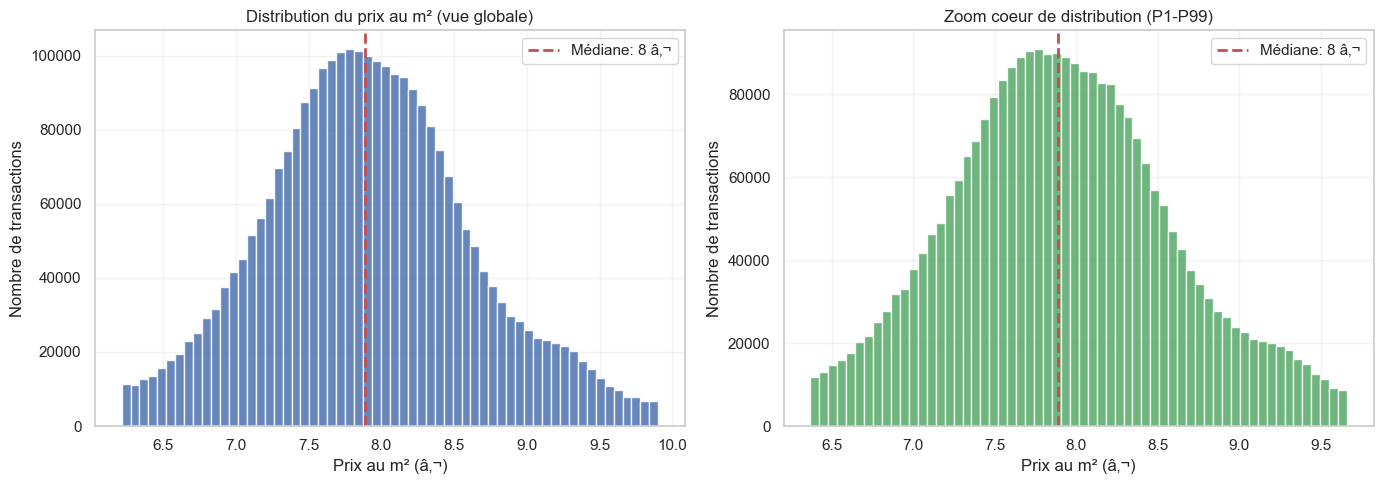

Lecture rapide : médiane = 8 â‚¬/m² | P1 = 6 â‚¬/m² | P99 = 10 â‚¬/m²


In [35]:
# Distribution du prix au m² après filtrage : vue globale + zoom central.
prix_m2 = df_model["log_prix_m2"].dropna()
q01, q99 = prix_m2.quantile([0.01, 0.99])
mediane = prix_m2.median()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Vue globale : montre la queue à droite.
axes[0].hist(prix_m2, bins=60, color="#4C72B0", alpha=0.85)
axes[0].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[0].set_title("Distribution du prix au m² (vue globale)")
axes[0].set_xlabel("Prix au m² (â‚¬)")
axes[0].set_ylabel("Nombre de transactions")
axes[0].grid(alpha=0.25)
axes[0].legend()

# 2) Zoom sur le coeur de distribution (1er-99e percentile) pour améliorer la lisibilité.
axes[1].hist(prix_m2, bins=60, range=(q01, q99), color="#55A868", alpha=0.85)
axes[1].axvline(mediane, color="#C44E52", linestyle="--", linewidth=2, label=f"Médiane: {mediane:,.0f} â‚¬")
axes[1].set_title("Zoom coeur de distribution (P1-P99)")
axes[1].set_xlabel("Prix au m² (â‚¬)")
axes[1].set_ylabel("Nombre de transactions")
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Lecture rapide : médiane = {mediane:,.0f} â‚¬/m² | P1 = {q01:,.0f} â‚¬/m² | P99 = {q99:,.0f} â‚¬/m²")

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de la cible log</h3>
  <div style="color: #4b5563; font-size: 14px;">Le log-prix présente une distribution beaucoup plus concentrée que le prix en euros. Cette cible est adaptée à une régression linéaire exploratoire .</div>
</div>

In [36]:
# Découpage train/test commun aux deux modèles.
indices = df_model.index

idx_train, idx_test = train_test_split(
    indices,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

X_bien_train = X_bien.loc[idx_train]
X_bien_test = X_bien.loc[idx_test]

X_contexte_train = X_contexte.loc[idx_train]
X_contexte_test = X_contexte.loc[idx_test]

y_train = y.loc[idx_train]
y_test = y.loc[idx_test]

print(f"Train : {len(idx_train):,} lignes")
print(f"Test : {len(idx_test):,} lignes")

Train : 2,144,439 lignes
Test : 714,814 lignes


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Découpage train/test</h3>
  <div style="color: #4b5563; font-size: 14px;">Le même découpage est utilisé pour les deux modèles afin que la comparaison soit équitable. Le test contient environ 715 000 observations, un volume suffisant pour mesurer les écarts de performance.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Construction de la baseline</h3>
  <div style="color: #4b5563; font-size: 14px;">Une première régression linéaire est construite uniquement à partir des caractéristiques du bien. Cette baseline sert de point de référence pour mesurer l’apport des variables territoriales et temporelles dans les modèles suivants.</div>
</div>

In [37]:
# Entraînement des deux modèles linéaires.
modele_bien = LinearRegression()
modele_contexte = LinearRegression()

modele_bien.fit(X_bien_train, y_train)
modele_contexte.fit(X_contexte_train, y_train)

pred_bien_log = modele_bien.predict(X_bien_test)
pred_contexte_log = modele_contexte.predict(X_contexte_test)

# Retour en euros/m² pour une lecture métier du MAE.
y_test_euros = np.exp(y_test)
pred_bien_euros = np.exp(pred_bien_log)
pred_contexte_euros = np.exp(pred_contexte_log)

In [38]:
# Comparaison des performances.
from sklearn.metrics import mean_squared_error

rmse_bien = np.sqrt(mean_squared_error(y_test_euros, pred_bien_euros))
rmse_contexte = np.sqrt(mean_squared_error(y_test_euros, pred_contexte_euros))

resultats_modeles = pd.DataFrame([
    {
        "modele": "Bien uniquement",
        "R2_log": r2_score(y_test, pred_bien_log),
        "MAE_euros_m2": mean_absolute_error(y_test_euros, pred_bien_euros),
        "RMSE_euros_m2": rmse_bien,
    },
    {
        "modele": "Bien + territoire + temps",
        "R2_log": r2_score(y_test, pred_contexte_log),
        "MAE_euros_m2": mean_absolute_error(y_test_euros, pred_contexte_euros),
        "RMSE_euros_m2": rmse_contexte,
    },
])

resultats_modeles["gain_R2_vs_baseline"] = (
    resultats_modeles["R2_log"] - resultats_modeles.loc[0, "R2_log"]
)
resultats_modeles["gain_MAE_vs_baseline"] = (
    resultats_modeles.loc[0, "MAE_euros_m2"] - resultats_modeles["MAE_euros_m2"]
)
resultats_modeles["gain_RMSE_vs_baseline"] = (
    resultats_modeles.loc[0, "RMSE_euros_m2"] - resultats_modeles["RMSE_euros_m2"]
)

display(resultats_modeles)

,modele,R2_log,MAE_euros_m2,RMSE_euros_m2,gain_R2_vs_baseline,gain_MAE_vs_baseline,gain_RMSE_vs_baseline
0,Bien uniquement,0.12,"1,780.21","2,922.71",0.00,0.00,0.00
1,Bien + territoire + temps,0.24,"1,574.20","2,658.02",0.12,206.00,264.68


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Comparaison des modèles</h3>
  <div style="color: #4b5563; font-size: 14px;">Le modèle enrichi par les variables territoriales et temporelles améliore de manière significative les performances par rapport au modèle basé uniquement sur les caractéristiques du bien. Le R² passe de 0,12 à 0,24, ce qui signifie que la part de variance expliquée est doublée. Les erreurs diminuent également avec un gain d’environ 206 €/m² sur la MAE et près de 265 €/m² sur la RMSE. Ces résultats confirment que la localisation et la temporalité apportent un signal prédictif important dans l’estimation des prix immobiliers.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Sortie transmise</h3>
  <div style="color: #4b5563; font-size: 14px;">Les décisions transmises à la suite sont de fait: travailler sur une base résidentielle mieux nettoyée, structurer les variables de bien, enrichir le contexte territorial, construire des comparables puis modéliser le prix au m² sur une feature store dédiée.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Plan des notebooks</h3>
  <div style="color: #4b5563; font-size: 14px;">Le tableau suivant présente la structure cible du pipeline. Il sert de feuille de route portfolio et garantit que chaque étape aura un rôle distinct, documenté et reproductible.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture du plan</h3>
  <div style="color: #4b5563; font-size: 14px;">Les notebooks 01 à 05 construisent la matière analytique ; les notebooks 06 à 11 structurent les variables et comparables ; les notebooks 12 et 13 concentrent la modélisation et la synthèse. Cette séparation rend le projet plus lisible sur GitHub.</div>
</div>

In [ ]:
# Plan de continuité du pipeline — structure finale des notebooks

plan_projet = pd.DataFrame([
    {
        "notebook": "00_cadrage_projet.ipynb",
        "objectif": "Poser le cadrage métier, la cible, le périmètre DVF et les hypothèses de départ.",
        "entree": "Projet DVF / besoin métier",
        "sortie": "Cadre analytique et fil directeur du pipeline",
    },
    {
        "notebook": "01_import_et_exploration_dvf.ipynb",
        "objectif": "Importer les données DVF, contrôler les colonnes, explorer la volumétrie et les premières distributions.",
        "entree": "Fichier DVF brut",
        "sortie": "Base DVF importée et diagnostic exploratoire initial",
    },
    {
        "notebook": "02_nettoyage_et_filtrage_residentiel.ipynb",
        "objectif": "Filtrer et fiabiliser le périmètre résidentiel exploitable.",
        "entree": "Base DVF importée",
        "sortie": "Base résidentielle nettoyée",
    },
    {
        "notebook": "03_definition_variables_bien_B3.ipynb",
        "objectif": "Construire les variables descriptives du bien : surface, pièces, type, prix au m², cohérences métier.",
        "entree": "Base résidentielle nettoyée",
        "sortie": "Base avec variables bien consolidées",
    },
    {
        "notebook": "04_rattachement_maillage_iris.ipynb",
        "objectif": "Rattacher les mutations aux zonages IRIS afin d’ajouter une granularité territoriale fine.",
        "entree": "Base avec variables bien + référentiel IRIS",
        "sortie": "Base géographiquement rattachée à l’IRIS",
    },
    {
        "notebook": "05_enrichissement_territorial_B2.ipynb",
        "objectif": "Ajouter des indicateurs territoriaux utiles à l’analyse du marché immobilier.",
        "entree": "Base rattachée IRIS + données territoriales externes",
        "sortie": "Base enrichie territorialement",
    },
    {
        "notebook": "06_typologies_marche_immobilier_B3.ipynb",
        "objectif": "Construire des typologies de marchés immobiliers locaux.",
        "entree": "Base enrichie territorialement",
        "sortie": "Segments ou typologies de marché",
    },
    {
        "notebook": "07_variables_temporelles_B4_et_taux_B6.ipynb",
        "objectif": "Créer les variables temporelles : année, trimestre, mois, ancienneté, dynamique de marché.",
        "entree": "Base enrichie et typologies",
        "sortie": "Base avec variables temporelles",
    },
    {
        "notebook": "08_construction_comparables_base_outils.ipynb",
        "objectif": "Construire les groupes de biens comparables selon des critères métier.",
        "entree": "Base complète avant comparables",
        "sortie": "Base avec groupes de comparables",
    },
    {
        "notebook": "09_features_comparables_B5.ipynb",
        "objectif": "Créer des variables issues des comparables : prix moyen, médian, dispersion, volume local.",
        "entree": "Base avec groupes de comparables",
        "sortie": "Base avec features de comparables",
    },
    {
        "notebook": "10_selection_features_et_scenarios.ipynb",
        "objectif": "Comparer plusieurs jeux de variables et scénarios de modélisation.",
        "entree": "Base featureisée",
        "sortie": "Features retenues et scénarios candidats",
    },
    {
        "notebook": "11_feature_store.ipynb",
        "objectif": "Préparer les données pour la modélisation : encodage, imputation, normalisation éventuelle, séparation train/test.",
        "entree": "Features retenues",
        "sortie": "Feature store prêt pour modèle",
    },
    {
        "notebook": "12_preprocessing_modelisation_prix_m2.ipynb",
        "objectif": "Entraîner, comparer et interpréter les modèles de prédiction du prix au m².",
        "entree": "Feature store",
        "sortie": "Modèles évalués et résultats interprétables",
    },
    {
        "notebook": "13_synthese_resultats_et_controle_antifuite_B5.ipynb",
        "objectif": "Synthétiser les résultats, les limites, les enseignements métier et les pistes d’amélioration.",
        "entree": "Résultats de modélisation",
        "sortie": "Synthèse finale du projet portfolio",
    },
])

display(plan_projet)

,notebook,objectif,entree,sortie
0,00_cadrage_projet.ipynb,"Poser le cadrage métier, la cible, le périmètr...",Projet DVF / besoin métier,Cadre analytique et fil directeur du pipeline
1,01_import_et_exploration_dvf.ipynb,"Importer les données DVF, contrôler les colonn...",Fichier DVF brut,Base DVF importée et diagnostic exploratoire i...
2,02_nettoyage_residentiel.ipynb,Filtrer et fiabiliser le périmètre résidentiel...,Base DVF importée,Base résidentielle nettoyée
3,03_definition_variables_bien.ipynb,Construire les variables descriptives du bien ...,Base résidentielle nettoyée,Base avec variables bien consolidées
4,04_rattachement_iris.ipynb,Rattacher les mutations aux zonages IRIS afin ...,Base avec variables bien + référentiel IRIS,Base géographiquement rattachée à l’IRIS
5,05_enrichissement_territorial.ipynb,Ajouter des indicateurs territoriaux utiles à ...,Base rattachée IRIS + données territoriales ex...,Base enrichie territorialement
6,06_typologies_marche_immobilier.ipynb,Construire des typologies de marchés immobilie...,Base enrichie territorialement,Segments ou typologies de marché
7,07_variables_temporelles.ipynb,"Créer les variables temporelles : année, trime...",Base enrichie et typologies,Base avec variables temporelles
8,08_construction_comparables.ipynb,Construire les groupes de biens comparables se...,Base complète avant comparables,Base avec groupes de comparables
9,09_features_comparables.ipynb,Créer des variables issues des comparables : p...,Base avec groupes de comparables,Base avec features de comparables


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Sortie du notebook 00</h3>
  <div style="color: #4b5563; font-size: 14px;">Le cadrage confirme trois points : la donnée DVF est exploitable sous conditions, le signal territorial est fort, et la modélisation bénéficie déjà des variables de contexte. Le notebook suivant peut donc approfondir l’import et l’exploration DVF sur une base mieux structurée.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion</h3>
  <div style="color: #4b5563; font-size: 14px;">Le notebook 00 valide la faisabilité du projet et fixe les règles de prudence. Il transforme une base brute massive et hétérogène en une première lecture métier documentée, sans masquer les limites de qualité et de périmètre.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Conclusion analytique</h3>
  <div style="color: #4b5563; font-size: 14px;">La cible prix/m² est pertinente mais sensible aux filtres. Les communes et les trimestres apportent un signal mesurable. Les modèles exploratoires montrent une amélioration avec le contexte, mais appellent des enrichissements plus fins avant toute utilisation opérationnelle.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Prochaine étape</h3>
  <div style="color: #4b5563; font-size: 14px;">Le notebook 01 reprendra le pipeline depuis l’import et l’exploration DVF afin de formaliser proprement la structure de données, les contrôles qualité et les premières tables de travail.</div>
</div>